# Krusell-Smith with the Sequence-Space Jacobian (SSJ)

The **Krusell-Smith (1998)** model is the canonical heterogeneous-agent (HA) macro model. Households face idiosyncratic labor-productivity risk and a borrowing constraint; they self-insure by saving in a single asset (physical capital). Aggregate dynamics are driven by TFP shocks.

The **Sequence-Space Jacobian (SSJ)** method of Auclert, Bardóczy, Rognlie, and Straub (2021, *Econometrica*) computes the exact linearized impulse responses of HA models without simulating the full nonlinear transition. The key insight is to represent each block of the model (household, firm, market clearing) as a map from sequences to sequences, differentiate via automatic differentiation and the *fake-news algorithm*, then solve for general equilibrium (GE) by inverting the resulting linear system.

This notebook: (1) calibrates the KS steady state; (2) builds SSJ Jacobians and visualises the fake-news matrix; (3) computes HA GE impulse responses to a TFP shock; (4) compares to a **near-representative-agent (near-RA)** benchmark that sets idiosyncratic risk to zero and removes the borrowing constraint — verifying the classic KS irrelevance result: in the KS model, HA and near-RA dynamics are nearly identical because precautionary saving has little effect on aggregate capital accumulation.

> **Reference**: Auclert, A., Bardóczy, B., Rognlie, M., & Straub, L. (2021). Using the Sequence-Space Jacobian to Solve and Estimate Heterogeneous-Agent Models. *Econometrica*, 89(5), 2375–2408.

In [1]:
# ── Packages and shared utilities ────────────────────────────────────────────
using Parameters, LinearAlgebra, SparseArrays
using Setfield, ForwardDiff, BasicInterpolators
using Roots, Plots, Colors

include("rouwenhorst.jl")
include("gensys.jl")
include("ssj_utils.jl")   # shared: build_Λ, inv_dist, get_E, build_J

build_J

## 1. Parameters

The model has two parameter structs:

- **`ModelParameters`**: structural/calibrated parameters (preferences, technology, shock processes). `β` and `Z_ss` are endogenously chosen in `get_steady_state` to hit `r_ss = r_target` and `Y_ss = 1`.
- **`NumericalParameters`**: discretisation choices (grid sizes, tolerances, horizon `T`). Wraps a `ModelParameters` instance and pre-computes the Rouwenhorst skill grid and transition matrix.

In [2]:
# ── Parameters ────────────────────────────────────────────────────────────────

"""
Structural / calibrated model parameters.

β and Z_ss are endogenously chosen in `get_steady_state` to hit
r_ss = r_target and Y_ss = 1 respectively.
"""
@with_kw struct ModelParameters{T}
    β::T    = 0.98                          # household discount factor (re-calibrated)
    σ::T    = 1.0                           # CRRA curvature  (σ = 1 → log utility)
    δ::T    = 0.025                         # capital depreciation rate
    α::T    = 0.4                           # capital income share
    Z_ss::T = 0.8                           # steady-state TFP (re-calibrated)
    ρs::T   = 0.966                         # AR(1) persistence of idiosyncratic skill
    σs::T   = (1.0 - ρs^2)^0.5 * 0.5       # std of skill innovations
    ρA::T   = 0.9                           # AR(1) persistence of aggregate TFP
    σA::T   = 0.007                         # std of TFP innovations
end

"""
Numerical / discretisation parameters.  Wraps a `ModelParameters` instance.
"""
@with_kw struct NumericalParameters{F,I}
    mp::ModelParameters{F} = ModelParameters()

    # asset grid
    na::I   = 500
    amin::F = 0.0       # borrowing limit
    amax::F = 100.0

    # idiosyncratic skill grid (Rouwenhorst discretisation)
    ns::I             = 7
    s_grid::Vector{F} = exp.(rouwenhorst(ns, mp.ρs, mp.σs)[2])
    Ps::Matrix{F}     = rouwenhorst(ns, mp.ρs, mp.σs)[1]

    # exponential asset grid — denser near the borrowing constraint
    a_grid::Vector{F} = _build_grid(amin, amax, na)

    tolHH::F = 1e-10    # EGM iteration convergence tolerance
    T::I     = 300      # sequence-space horizon
end

"""
    _build_grid(amin, amax, na)

Exponential asset grid on [amin, amax] with `na` points, denser near the
borrowing constraint.

The formula `exp.(range(0, log(amax−amin+1); length=na)) .+ amin .- 1` maps
[0, log(amax−amin+1)] → [amin, amax] with exponential spacing regardless of
the sign of amin.  For negative amin the shift `amax−amin+1 > 1` still holds,
so the grid works correctly — important for the near-RA case where `amin = −50`.
"""
function _build_grid(amin, amax, na)
    return exp.(range(0.0; stop=log(amax - amin + 1.0), length=na)) .+ amin .- 1.0
end

_exp_grid(amin, amax, na) = _build_grid(amin, amax, na)

_exp_grid (generic function with 1 method)

## 2. Household Problem — Endogenous Grid Method (EGM)

Each period, households choose consumption `c` and savings `a'` to maximize expected lifetime utility subject to a budget constraint and borrowing limit.

The **EGM** (Carroll, 2006) solves the household problem by inverting the Euler equation:

1. **`update_EVa`**: Given next-period consumption policy `c'`, compute the expected marginal utility of saving: `EVa = (1+r') · (c')^{-σ} · Ps'`.
2. **Invert the Euler equation**: `c_endog = (β · EVa)^{-1/σ}` gives consumption on the *endogenous* grid.
3. **Recover the endogenous asset grid**: from the budget constraint, `a_endog = (c_endog - w·s + a_grid) / (1+r)`.
4. **Interpolate** back onto the fixed exogenous grid and enforce the borrowing constraint.
5. **`solve_EGM_SS`**: Iterate to steady-state convergence.

In [3]:
# ── Household EGM ─────────────────────────────────────────────────────────────

"""
    update_EVa(cpol, r, np) → EVa  [na × ns]

Expected marginal utility of assets tomorrow, integrated over the skill
transition matrix Ps.  The (1+r) converts from utils of consumption to
utils of saving.
"""
function update_EVa(cpol::AbstractArray, r::T, np::NumericalParameters) where {T<:Real}
    return (1.0 + r) .* (cpol .^ (-np.mp.σ)) * np.Ps'
end

"""
    EGM_update(cPrime, w, r, rPrime, np) → (c, aPrime)  [na × ns each]

One backward EGM step.
"""
function EGM_update(cPrime::AbstractArray, w, r, rPrime, np::NumericalParameters)
    @unpack mp, a_grid, s_grid, ns, na, amin = np
    @unpack β, σ = mp

    EVa     = update_EVa(cPrime, rPrime, np)
    c_endog = (β .* EVa) .^ (-1 / σ)               # Euler equation inversion
    if any(<=(0), c_endog)
        c_endog = max.(1e-10, c_endog)
    end

    inc     = w .* s_grid                            # labour income by skill type
    a_endog = (c_endog .- inc' .+ a_grid) ./ (1.0 + r)  # endogenous asset grid

    constr  = a_endog[1, :]                          # constraint threshold per skill
    aPrime  = zeros(eltype(a_endog), na, ns)
    ag      = a_grid .+ zeros(eltype(a_endog), 1)   # type-promote for ForwardDiff

    @views for si in 1:ns
        itp            = LinearInterpolator(a_endog[:, si], ag, NoBoundaries())
        aPrime[:, si]  = itp.(ag)
        aPrime[a_grid .< constr[si], si] .= amin     # enforce borrowing constraint
    end

    c = (1 + r) .* a_grid .+ inc' .- aPrime          # recover c from budget constraint
    return c, aPrime
end

"""
    solve_EGM_SS(cGuess, wSS, rSS, np; max_iter, verbose) → (c, a)

Iterate the EGM backward step to convergence starting from `cGuess`.
Returns steady-state consumption and savings policies.
"""
function solve_EGM_SS(cGuess::AbstractArray, wSS, rSS, np::NumericalParameters;
                      max_iter::Int=3000, verbose::Bool=false)
    c0 = copy(cGuess)
    local c1, a1
    dist = Inf; iter = 0

    while dist > np.tolHH && iter < max_iter
        c1, a1 = EGM_update(c0, wSS, rSS, rSS, np)
        dist   = maximum(abs.(c1 .- c0))
        verbose && rem(iter, 100) == 0 &&
            println("  iter $iter  |  dist = $(round(dist; sigdigits=3))")
        c0   = copy(c1)
        iter += 1
    end

    iter == max_iter && @warn "solve_EGM_SS: did not converge in $max_iter iterations."
    println("EGM converged in $iter iters  (dist = $(round(dist; sigdigits=3)))")
    return c1, a1
end

"""
    solve_EGM_SS(wSS, rSS, np; kwargs...) → (c, a)

Convenience wrapper: builds a sensible initial guess automatically.
"""
function solve_EGM_SS(wSS, rSS, np::NumericalParameters; kwargs...)
    incs    = wSS .* np.s_grid
    r_use   = max(rSS, 0.01)
    pdv_inc = incs' ./ r_use                        # [1 × ns]  permanent income
    total_w = (1 + rSS) .* np.a_grid .+ pdv_inc    # [na × ns] total wealth
    c_guess = max.(1e-6, 0.05 .* total_w)
    return solve_EGM_SS(c_guess, wSS, rSS, np; kwargs...)
end

solve_EGM_SS

## 3. Distribution

The state space is the joint distribution over (asset, skill) pairs. With `na` asset grid points and `ns` skill states, the distribution is a vector of length `na·ns`.

**`build_Λ`** constructs the sparse Markov transition matrix for this distribution using linear interpolation weights on the asset grid. **`inv_dist`** computes the stationary distribution via a sparse linear solve.

<!-- build_Λ and inv_dist are defined in ssj_utils.jl -->

## 4. Steady-State Calibration

We calibrate to three targets:
- **`r_ss = r_target`**: achieved by choosing `β` so that the asset market clears at the target interest rate.
- **`Y_ss = 1`**: normalization, achieved by choosing `Z_ss`.
- **`L_ss = 1`**: normalization of the skill grid.

`β_objective` returns the relative gap between implied aggregate savings and the target capital stock. `get_steady_state` finds the root using Brent's method.

In [4]:
# ── Steady-state calibration ──────────────────────────────────────────────────

"""
    β_objective(β, K_target, r_ss, w_ss, np) → residual

Returns the relative gap between implied aggregate savings and `K_target`.
Used as the root to find in `get_steady_state`.
"""
function β_objective(β, K_target, r_ss, w_ss, np::NumericalParameters)
    @set! np.mp.β = β
    c_ss, a_ss    = solve_EGM_SS(w_ss, r_ss, np)
    Λ             = build_Λ(a_ss, np)
    D             = reshape(inv_dist(Λ), np.na, np.ns)
    K_implied     = sum(D .* a_ss)
    return K_implied / K_target - 1
end

"""
    get_steady_state(r_target, np) → (K_ss, L, w_ss, c_ss, a_ss, D_ss, np_cal)

Calibrate the model to hit r_ss = r_target (by choosing β) and Y_ss = 1
(by choosing Z_ss).  Returns steady-state aggregates, policies, distribution,
and calibrated NumericalParameters.
"""
function get_steady_state(r_target, np::NumericalParameters)
    @unpack mp, s_grid, na, ns = np
    @unpack δ, α = mp

    # normalise labour supply to 1
    s_dist = inv_dist(np.Ps)
    L      = dot(s_dist, np.s_grid)
    @set! np.s_grid = np.s_grid ./ L
    L = 1.0

    # capital implied by the r target: K/Y = α/(r+δ), Y = 1 → K = K/Y
    KoverY_ss = α / (r_target + δ)
    K_ss      = KoverY_ss

    # choose Z_ss so that Y = Z K^α L^(1−α) = 1
    Z_ss = 1.0 / (K_ss^α * L^(1 - α))
    @set! np.mp.Z_ss = Z_ss

    # steady-state wage from firm's FOC
    w_ss = (1 - α) * Z_ss * (K_ss / L)^α

    # calibrate β to clear the asset market
    β_cal = find_zero(b -> β_objective(b, K_ss, r_target, w_ss, np), np.mp.β)
    @set! np.mp.β = β_cal
    println("Calibrated  β = $(round(β_cal; digits=6)),  Z_ss = $(round(Z_ss; digits=4))")

    # remaining steady-state objects
    c_ss, a_ss = solve_EGM_SS(w_ss, r_target, np)
    D_ss       = reshape(inv_dist(build_Λ(a_ss, np)), na, ns)

    return K_ss, L, w_ss, c_ss, a_ss, D_ss, np
end

get_steady_state

## 5. SSJ Building Blocks

The SSJ method decomposes the model into **blocks** (household, firm, market clearing), each represented as a linear map from input sequences to output sequences. The **fake-news algorithm** (Auclert et al. 2021, Appendix C) computes the Jacobian of each block efficiently:

1. **Backward iteration** (`backward_objective`): Perturb a single input (wage `w` or interest rate `r`) at date `T` and iterate the EGM backward, recording the aggregate savings and distribution responses at each date.
2. **ForwardDiff** (`get_Y_D`): Differentiate `backward_objective` w.r.t. the shock size at zero, yielding the "date-0 impulses" Y and D.
3. **Fake-news + Jacobian** (`build_J` in `ssj_utils.jl`): Combine Y, D, and the expectation matrix E into the full T×T Jacobian.

`get_E` and `build_J` are shared in `ssj_utils.jl`.

In [5]:
# ── SSJ backward iteration and Y, D impulses ─────────────────────────────────

"""
    backward_objective(dx_w, dx_r, c_ss, w_ss, r_ss, D_ss, np)
        → vcat(K_terms, D_terms[:])

Backward iteration for the fake-news algorithm (Auclert et al. 2021).

Perturbs (w, r) at the terminal date T of the backward loop by (dx_w, dx_r),
then propagates the EGM update backward.  Records at each date t:
  - K_terms[t]   : aggregate savings response  (scalar)
  - D_terms[:,t] : distribution response       (na·ns vector)

Re-centering (Appendix C, Auclert et al. 2021) ensures the output is
zero at steady state, so ForwardDiff isolates the exact derivative.
"""
function backward_objective(dx_w, dx_r, c_ss, w_ss, r_ss, D_ss,
                            np::NumericalParameters)
    @unpack T = np
    type_ind = dx_w + dx_r

    K_terms = zeros(eltype(type_ind), T)
    D_terms = zeros(eltype(type_ind), length(D_ss), T)

    # re-centering baseline: EGM at exact steady state
    c_nc = EGM_update(c_ss, w_ss, r_ss, r_ss, np)[1]
    c_rc = copy(c_ss)

    for tt in Iterators.reverse(1:T)
        if tt == T
            c_t, aPrime_t = EGM_update(c_rc, w_ss + dx_w, r_ss + dx_r, r_ss, np)
        elseif tt == T - 1
            c_t, aPrime_t = EGM_update(c_rc, w_ss, r_ss, r_ss + dx_r, np)
        else
            c_t, aPrime_t = EGM_update(c_rc, w_ss, r_ss, r_ss, np)
        end

        Λ = build_Λ(aPrime_t, np)
        K_terms[tt]    = dot(vec(aPrime_t), vec(D_ss))
        D_terms[:, tt] = Λ' * vec(D_ss)

        # re-center so output is zero absent the shock
        c_rc = c_ss .+ (c_t .- c_nc)
    end

    return vcat(K_terms, vec(D_terms))
end

"""
    get_Y_D(c_ss, w_ss, r_ss, D_ss, np) → (Y_w, D_w, Y_r, D_r)

Differentiate `backward_objective` w.r.t. (dx_w, dx_r) at zero via
ForwardDiff, yielding date-0 impulses of aggregate savings and the
distribution in response to wage and interest-rate shocks.
"""
function get_Y_D(c_ss, w_ss, r_ss, D_ss, np::NumericalParameters)
    @unpack T, na, ns = np

    obj(x) = backward_objective(x[1], x[2], c_ss, w_ss, r_ss, D_ss, np)
    derivs  = ForwardDiff.jacobian(obj, zeros(2))

    # reverse() re-orders from backward-iteration time to forward calendar time
    Y_w = reverse(derivs[1:T,     1])
    D_w = reverse(reshape(derivs[(T+1):end, 1], (na * ns, T)); dims=2)
    Y_r = reverse(derivs[1:T,     2])
    D_r = reverse(reshape(derivs[(T+1):end, 2], (na * ns, T)); dims=2)

    return Y_w, D_w, Y_r, D_r
end 

get_Y_D

## 6. GE Jacobian & Impulse Responses

In GE, asset market clearing pins down the capital stock: `K = J_r · dr + J_w · dw`. Firm FOCs link prices to capital and TFP: `dr = (∂r/∂K) dK + (∂r/∂Z) dZ` and similarly for `dw`. Substituting:

$$[I - J_r \tfrac{\partial r}{\partial K} - J_w \tfrac{\partial w}{\partial K}]\, dK = [J_r \tfrac{\partial r}{\partial Z} + J_w \tfrac{\partial w}{\partial Z}]\, dZ$$

This is a T×T linear system solved once for the full path of capital.

`GE_impulse_responses` works for any `np` (HA or near-RA), enabling a clean comparison.

In [6]:
# ── GE Jacobian and impulse responses ────────────────────────────────────────

"""
    GE_impulse_responses(K_ss, L, w_ss, r_ss, c_ss, a_ss, D_ss, np)
        → (irf_K, irf_Y, irf_C, irf_r, irf_w)

General-equilibrium impulse responses to a one-standard-deviation TFP shock
using the SSJ method.  Works for any `np` — used for both HA and near-RA.

Returns IRFs as percentage deviations from steady state.
"""
function GE_impulse_responses(K_ss, L, w_ss, r_ss, c_ss, a_ss, D_ss,
                              np::NumericalParameters)
    @unpack mp, T = np
    @unpack α, δ, ρA, σA, Z_ss = mp

    # AR(1) TFP impulse (one s.d. shock at t = 0)
    dZ = σA .* ρA .^ (0:(T-1))

    # partial derivatives of prices w.r.t. K and Z at steady state
    dr_dK = α * (α - 1) * Z_ss * K_ss^(α - 2) * L^(1 - α)
    dr_dZ = α             * K_ss^(α - 1) * L^(1 - α)
    dw_dK = α * (1 - α)  * Z_ss * K_ss^(α - 1) * L^(-α)
    dw_dZ = (1 - α)       * K_ss^α       * L^(-α)

    # SSJ Jacobians
    Λ = build_Λ(a_ss, np)
    E = get_E(Λ, a_ss, np.T)
    Y_w, D_w, Y_r, D_r = get_Y_D(c_ss, w_ss, r_ss, D_ss, np)
    J_r, _ = build_J(Y_r, D_r, E, np.T)
    J_w, _ = build_J(Y_w, D_w, E, np.T)

    # GE system:  M dK = RHS · dZ
    I_T = I(T)
    M   = I_T .- J_r .* dr_dK .- J_w .* dw_dK
    RHS = (J_r .* dr_dZ .+ J_w .* dw_dZ) * dZ
    dK  = M \ RHS

    # recover remaining aggregate paths
    dr = dr_dK .* dK .+ dr_dZ .* dZ
    dw = dw_dK .* dK .+ dw_dZ .* dZ

    Y_ss = Z_ss * K_ss^α * L^(1 - α)
    C_ss = Y_ss - δ * K_ss

    dY_dZ = K_ss^α * L^(1 - α)
    dY_dK = α * Z_ss * K_ss^(α - 1) * L^(1 - α)
    dY    = dY_dZ .* dZ .+ dY_dK .* dK
    dC    = dY .- δ .* dK

    irf_K = 100 .* dK ./ K_ss
    irf_Y = 100 .* dY ./ Y_ss
    irf_C = 100 .* dC ./ C_ss
    irf_r = 100 .* dr ./ r_ss
    irf_w = 100 .* dw ./ w_ss

    return irf_K, irf_Y, irf_C, irf_r, irf_w
end

GE_impulse_responses

## 7. Near-RA Approximation

The **near-representative-agent (near-RA)** limit is achieved by two parameter changes:

1. **`σs → 0`**: Eliminates idiosyncratic income risk, removing the precautionary saving motive.
2. **`amin → −∞`**: The borrowing constraint becomes non-binding, eliminating the "Aiyagari wedge".

In this limit, all households make identical saving decisions, the wealth distribution collapses to a point mass, and aggregate dynamics converge to a representative-agent RBC model. **KS (1998) show that, in their model, HA and near-RA IRFs are nearly identical** — heterogeneity has little aggregate effect.

*Implementation note*: `σs = 0` exactly would give a degenerate Rouwenhorst matrix; we use `σs = 0.005` as a numerically safe approximation.

In [7]:
# ── Near-RA parameter constructor ─────────────────────────────────────────────

"""
    make_near_RA_params(np; σs_lo=0.005, amin_ra=-50.0) → NumericalParameters

Construct NumericalParameters for the near-RA limit:
  σs → 0 (no idiosyncratic risk) and amin → −∞ (non-binding constraint).
"""
function make_near_RA_params(np::NumericalParameters;
                              σs_lo::Float64 = 0.005,
                              amin_ra::Float64 = -50.0)
    mp_ra = ModelParameters(β    = np.mp.β,
                            σ    = np.mp.σ,
                            δ    = np.mp.δ,
                            α    = np.mp.α,
                            Z_ss = np.mp.Z_ss,
                            ρs   = np.mp.ρs,
                            σs   = σs_lo,
                            ρA   = np.mp.ρA,
                            σA   = np.mp.σA)
    return NumericalParameters(mp    = mp_ra,
                               na    = np.na,
                               ns    = np.ns,
                               amin  = amin_ra,
                               amax  = np.amax,
                               tolHH = np.tolHH,
                               T     = np.T)
end

make_near_RA_params

## 8. Plots

In [8]:
# ── Plot functions ─────────────────────────────────────────────────────────────

"""
    plot_consumption_policies(ha_c, ha_np, nra_c, nra_np; a_max_plot, save_path)

Three-panel figure comparing HA and near-RA consumption policies.
  Left   : HA c(a, s) by skill type.
  Centre : HA vs near-RA for median skill.
  Right  : Gap c_HA − c_near-RA, highlighting borrowing constraint and
           precautionary saving channels.
"""
function plot_consumption_policies(ha_c, ha_np, nra_c, nra_np;
                                   a_max_plot::Real=2,
                                   save_path::Union{String,Nothing}=nothing)

    ha_ag  = ha_np.a_grid
    nra_ag = nra_np.a_grid
    ha_ns  = ha_np.ns
    lw     = 2.0

    skill_colours = [RGB(1 - si/(ha_ns-1), 0.2, si/(ha_ns-1)) for si in 0:(ha_ns-1)]

    ha_idx  = ha_ag  .<= a_max_plot
    nra_idx = nra_ag .<= a_max_plot

    c_max = maximum(ha_c[ha_idx, :]) * 1.05

    p1 = plot(; xlabel="assets  a", ylabel="consumption  c",
              title="HA  c(a, s)  by skill type",
              xlims=(ha_np.amin, a_max_plot), ylims=(0, c_max),
              legend=:topleft, grid=true, gridalpha=0.3)
    for si in 1:ha_ns
        label = si == 1 ? "low skill" : si == ha_ns ? "high skill" : ""
        plot!(p1, ha_ag[ha_idx], ha_c[ha_idx, si];
              lw, color=skill_colours[si], label=label, alpha=0.85)
    end

    mid = ceil(Int, ha_ns / 2)
    p2 = plot(; xlabel="assets  a", ylabel="consumption  c",
              title="HA vs near-RA  (median skill)",
              xlims=(ha_np.amin, a_max_plot), ylims=(0, c_max),
              legend=:topleft, grid=true, gridalpha=0.3)
    plot!(p2, ha_ag[ha_idx],  ha_c[ha_idx, mid];
          lw, color=:steelblue, label="HA")
    plot!(p2, nra_ag[nra_idx], nra_c[nra_idx, mid];
          lw, color=:firebrick, label="near-RA (unconstrained)", ls=:dash)

    nra_itp    = LinearInterpolator(nra_ag, nra_c[:, mid], NoBoundaries())
    nra_on_ha  = nra_itp.(ha_ag)
    gap        = ha_c .- nra_on_ha

    gap_min = minimum(gap[ha_idx, :])
    gap_max = maximum(gap[ha_idx, :])
    gap_pad = (gap_max - gap_min) * 0.1

    p3 = plot(; xlabel="assets  a",
              ylabel="c_HA − c_near-RA",
              title="Consumption wedge: HA − near-RA",
              xlims=(ha_np.amin, a_max_plot),
              ylims=(gap_min - gap_pad, gap_max + gap_pad),
              legend=:topright, grid=true, gridalpha=0.3)
    hline!(p3, [0]; lw=1, color=:black, ls=:dot, label="")
    for si in 1:ha_ns
        label = si == 1 ? "low skill" : si == ha_ns ? "high skill" : ""
        plot!(p3, ha_ag[ha_idx], gap[ha_idx, si];
              lw, color=skill_colours[si], label=label, alpha=0.85)
    end
    x_left  = ha_np.amin + (a_max_plot - ha_np.amin) * 0.05
    x_right = ha_np.amin + (a_max_plot - ha_np.amin) * 0.55
    y_ann   = gap_min + gap_pad * 0.5
    annotate!(p3, x_left,  y_ann, text("binding\nconstraint", 7, :left, :darkred))
    annotate!(p3, x_right, y_ann, text("precautionary\nsaving",    7, :left, :gray))

    fig = plot(p1, p2, p3;
               layout=(1, 3), size=(1200, 400),
               plot_title="Consumption policy functions — HA vs near-RA (unconstrained)",
               left_margin=5Plots.mm, bottom_margin=5Plots.mm)

    !isnothing(save_path) && savefig(fig, save_path)
    return fig
end

"""
    plot_distributions(ha_D, ha_np, nra_D, nra_np; a_max_plot, save_path)

Two-panel comparison of steady-state marginal asset distributions (linear and log scale).
"""
function plot_distributions(ha_D, ha_np, nra_D, nra_np;
                            a_max_plot::Real=20,
                            save_path::Union{String,Nothing}=nothing)

    ha_ag  = ha_np.a_grid
    nra_ag = nra_np.a_grid
    lw     = 2.5

    ha_marg  = sum(ha_D;  dims=2)[:]
    nra_marg = sum(nra_D; dims=2)[:]

    ha_idx  = (ha_ag  .>= 0) .& (ha_ag  .<= a_max_plot)
    nra_idx = (nra_ag .>= 0) .& (nra_ag .<= a_max_plot)

    p1 = plot(ha_ag[ha_idx], ha_marg[ha_idx];
              lw, color=:steelblue, label="HA  (σs=$(round(ha_np.mp.σs; digits=3)))",
              xlabel="assets  a", ylabel="density",
              title="Marginal wealth distribution",
              legend=:topright, grid=true, gridalpha=0.3)
    plot!(p1, nra_ag[nra_idx], nra_marg[nra_idx];
          lw, color=:firebrick, label="near-RA  (σs=$(round(nra_np.mp.σs; digits=3)))",
          ls=:dash)

    ha_marg_pos  = max.(ha_marg,  1e-12)
    nra_marg_pos = max.(nra_marg, 1e-12)
    xmax_log     = min(ha_np.amax, 100.0)

    p2 = plot(ha_ag, ha_marg_pos;
              lw, color=:steelblue, label="HA",
              xlims=(0, xmax_log), yscale=:log10,
              xlabel="assets  a", ylabel="density (log₁₀ scale)",
              title="Marginal wealth dist. — log scale",
              legend=:topright, grid=true, gridalpha=0.3)
    plot!(p2, nra_ag, nra_marg_pos;
          lw, color=:firebrick, label="near-RA", ls=:dash)

    fig = plot(p1, p2;
               layout=(1, 2), size=(900, 380),
               plot_title="Steady-state wealth distributions — HA vs near-RA (unconstrained)",
               left_margin=5Plots.mm, bottom_margin=5Plots.mm)

    !isnothing(save_path) && savefig(fig, save_path)
    return fig
end

"""
    plot_irfs(ha, nra; T_plot, save_path)

Plot HA vs near-RA impulse responses for K, Y, C, r, w.
"""
function plot_irfs(ha::NamedTuple, nra::NamedTuple; T_plot::Int=60,
                   save_path::Union{String,Nothing}=nothing)
    tt  = 1:T_plot
    lw  = 2.5

    function panel(ha_irf, nra_irf, ylab, title)
        plot(tt, ha_irf[tt]; lw, color=:steelblue, label="HA",
             xlabel="quarters", ylabel=ylab, title=title,
             legend=:topright, grid=true, gridalpha=0.3)
        plot!(tt, nra_irf[tt]; lw, color=:firebrick, label="near-RA (unconstrained)",
              ls=:dash)
    end

    p1 = panel(ha.K, nra.K, "% dev. SS", "Capital  K")
    p2 = panel(ha.Y, nra.Y, "% dev. SS", "Output   Y")
    p3 = panel(ha.C, nra.C, "% dev. SS", "Consumption  C")
    p4 = panel(ha.r, nra.r, "% dev. SS", "Interest rate  r")
    p5 = panel(ha.w, nra.w, "% dev. SS", "Wage  w")

    fig = plot(p1, p2, p3, p4, p5;
               layout=(2, 3), size=(1100, 620),
               plot_title="HA vs near-RA — TFP shock (KS: heterogeneity should be small)",
               left_margin=5Plots.mm, bottom_margin=5Plots.mm)

    !isnothing(save_path) && savefig(fig, save_path)
    return fig
end

"""
    plot_irfs(ha; T_plot, save_path)

Single-model IRF plot (HA only).
"""
function plot_irfs(ha::NamedTuple; T_plot::Int=60,
                   save_path::Union{String,Nothing}=nothing)
    tt  = 1:T_plot
    lw  = 2.5

    function panel(ha_irf, ylab, title)
        plot(tt, ha_irf[tt]; lw, color=:steelblue, label="HA",
             xlabel="quarters", ylabel=ylab, title=title,
             legend=:topright, grid=true, gridalpha=0.3)
    end

    p1 = panel(ha.K,  "% dev. SS", "Capital  K")
    p2 = panel(ha.Y,  "% dev. SS", "Output   Y")
    p3 = panel(ha.C,  "% dev. SS", "Consumption  C")
    p4 = panel(ha.r,  "% dev. SS", "Interest rate  r")
    p5 = panel(ha.w,  "% dev. SS", "Wage  w")

    fig = plot(p1, p2, p3, p4, p5;
               layout=(2, 3), size=(1100, 620),
               plot_title="TFP shock impulse responses",
               left_margin=5Plots.mm, bottom_margin=5Plots.mm)

    !isnothing(save_path) && savefig(fig, save_path)
    return fig
end

plot_irfs

## 9. Main Script — Step 1: Steady-State Calibration

In [9]:
# ── Step 1: Calibrate HA steady state ────────────────────────────────────────
println("=" ^ 60)
println("Step 1: Steady-state calibration  [HA]")
println("=" ^ 60)

r_ss    = 0.01
mp      = ModelParameters(ρs=0.2)
np_base = NumericalParameters(mp=mp)

@time K_ss, L, w_ss, c_ss, a_ss, D_ss, np =
    get_steady_state(r_ss, np_base)

Step 1: Steady-state calibration  [HA]
EGM converged in 302 iters  (dist = 9.14e-11)
EGM converged in 302 iters  (dist = 9.02e-11)
EGM converged in 154 iters  (dist = 8.84e-11)
EGM converged in 367 iters  (dist = 9.61e-11)
EGM converged in 541 iters  (dist = 9.93e-11)
EGM converged in 2970 iters  (dist = 9.97e-11)
EGM converged in 1775 iters  (dist = 9.97e-11)
EGM converged in 3000 iters  (dist = 4.25e-8)


┌ Warning: solve_EGM_SS: did not converge in 3000 iterations.
└ @ Main In[3]:67


EGM converged in 1838 iters  (dist = 9.97e-11)
EGM converged in 1790 iters  (dist = 9.94e-11)
EGM converged in 1807 iters  (dist = 9.98e-11)
EGM converged in 1823 iters  (dist = 9.97e-11)
EGM converged in 1815 iters  (dist = 9.95e-11)
EGM converged in 1812 iters  (dist = 9.99e-11)
EGM converged in 1812 iters  (dist = 9.96e-11)
EGM converged in 1812 iters  (dist = 9.98e-11)
EGM converged in 1812 iters  (dist = 9.98e-11)
EGM converged in 1812 iters  (dist = 9.97e-11)
EGM converged in 1812 iters  (dist = 9.98e-11)
EGM converged in 1812 iters  (dist = 9.98e-11)
EGM converged in 1812 iters  (dist = 9.98e-11)
Calibrated  β = 0.989967,  Z_ss = 0.3774
EGM converged in 1812 iters  (dist = 9.98e-11)
 12.024273 seconds (23.17 M allocations: 12.636 GiB, 7.02% gc time, 26.81% compilation time: 2% of which was recompilation)


(11.428571428571429, 1.0, 0.6, [0.1557174761028496 0.23422720484490134 … 0.5403779913433646 0.5728196828118992; 0.16510203275843488 0.2436117615004866 … 0.5409913353085615 0.5731683165400796; … ; 1.6048733101225565 1.6061661760575419 … 1.618242016945544 1.6250168043481352; 1.61430052950368 1.6155933981347914 … 1.627669255780674 1.6344440515203047], [0.0 0.0 … 0.6586719024631529 1.2307678921008751; 0.0 0.0 … 0.6674431151535413 1.23980381502828; … ; 98.61172985609024 98.6889467188973 … 99.64169356697091 100.23945646067457; 99.5414169465992 99.61863380671014 … 100.57138063802587 101.16914352339249], [8.6579775798977e-6 4.250050801385266e-5 … 1.6693779470618094e-5 2.143199696101911e-6; 1.118390696438956e-6 5.7108815799625e-6 … 2.5229465676946395e-6 3.3066372376939886e-7; … ; 1.7075821228808097e-9 1.03402473681662e-8 … 1.075828242868895e-8 1.8130878266687816e-9; 1.3583918741902496e-9 8.666618763727832e-9 … 1.1229052461030014e-8 2.0026460462526562e-9], NumericalParameters{Float64, Int64}
  m

### Step 2: SSJ Jacobians + Fake-News Matrix


Step 2: Building SSJ Jacobians  [HA]


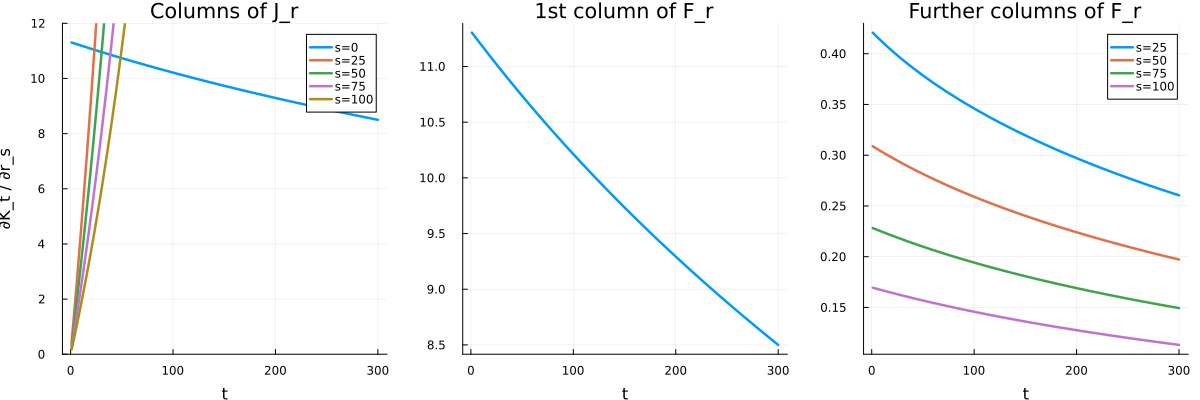

In [10]:
# ── Step 2: Build SSJ Jacobians ───────────────────────────────────────────────
println("\n", "=" ^ 60)
println("Step 2: Building SSJ Jacobians  [HA]")
println("=" ^ 60)

Λ_ss                = build_Λ(a_ss, np)
E_ss                = get_E(Λ_ss, a_ss, np.T)
Y_w, D_w, Y_r, D_r = get_Y_D(c_ss, w_ss, r_ss, D_ss, np)
J_r, F_r            = build_J(Y_r, D_r, E_ss, np.T)
J_w, F_w            = build_J(Y_w, D_w, E_ss, np.T)

# Reproduce Figure 2 from Auclert et al. (2021) — selected columns of J_r
let
    cols = 1 .+ [0, 25, 50, 75, 100]
    p1 = plot(1:np.T, J_r[:, cols]; lw=2.5,
              labels=["s=0" "s=25" "s=50" "s=75" "s=100"],
              ylims=(0, 12), legend=:topright,
              title="Columns of J_r", xlabel="t", ylabel="∂K_t / ∂r_s")
    p2 = plot(1:np.T, F_r[:, 1]; lw=2.5, legend=false,
              title="1st column of F_r", xlabel="t")
    p3 = plot(1:np.T, F_r[:, 1 .+ [25, 50, 75, 100]]; lw=2.5,
              labels=["s=25" "s=50" "s=75" "s=100"],
              title="Further columns of F_r", xlabel="t")
    display(plot(p1, p2, p3; size=(1200, 400), layout=(1, 3),
                 left_margin=4Plots.mm, bottom_margin=4Plots.mm))
end

### Step 3: HA Impulse Responses


Step 3: HA impulse responses
  [HA] Computing GE impulse responses...
  0.776867 seconds (2.91 M allocations: 2.447 GiB, 13.08% gc time, 39.80% compilation time)


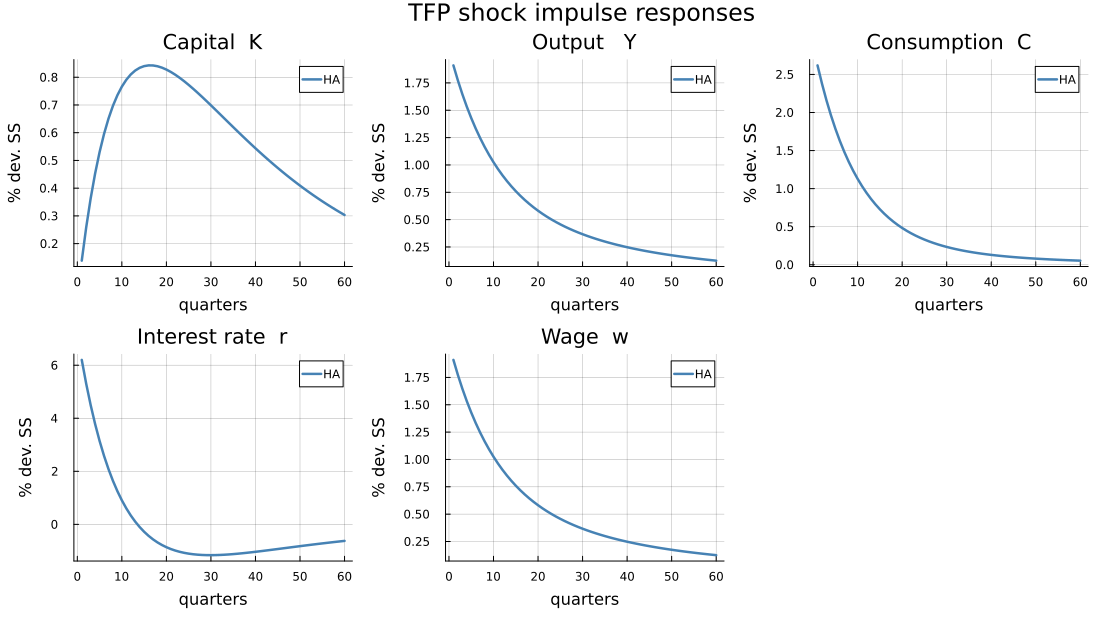

In [11]:
# ── Step 3: HA GE impulse responses ──────────────────────────────────────────
println("\n", "=" ^ 60)
println("Step 3: HA impulse responses")
println("=" ^ 60)

println("  [HA] Computing GE impulse responses...")
@time ha_K, ha_Y, ha_C, ha_r, ha_w =
    GE_impulse_responses(K_ss, L, w_ss, r_ss, c_ss, a_ss, D_ss, np)

fig_irf_ha = plot_irfs((K=ha_K, Y=ha_Y, C=ha_C, r=ha_r, w=ha_w);
                        T_plot=60, save_path="irf_ha.png")
display(fig_irf_ha)

### Step 3b: Near-RA Benchmark — Testing the KS (1998) Irrelevance Result

**Krusell and Smith (1998)** showed that, in their model, heterogeneity has little effect on aggregate dynamics: the aggregate law of motion is well-approximated by the representative-agent model. Intuitively, in a model with capital as the only asset and relatively complete markets (Bewley-Aiyagari-Hugget structure), precautionary saving shifts the level of capital but does not substantially change its response to aggregate shocks.

We verify this result by comparing the full HA model to the near-RA limit. If the KS result holds, the two IRFs should be nearly identical. This also validates our SSJ implementation.

In [12]:
# ── Step 3b: Near-RA calibration and GE IRFs ─────────────────────────────────
println("\n", "=" ^ 60)
println("Step 3b: Near-RA HA impulse responses")
println("=" ^ 60)

np_nra = make_near_RA_params(np; σs_lo=0.005, amin_ra=-50.0)
println("  Calibrating near-RA SS  (σs=$(np_nra.mp.σs), amin=$(np_nra.amin))...")
@time K_nra, L_nra, w_nra, c_nra, a_nra, D_nra, np_nra =
    get_steady_state(r_ss, np_nra)

println("  Computing near-RA GE impulse responses...")
@time nra_K, nra_Y, nra_C, nra_r, nra_w =
    GE_impulse_responses(K_nra, L_nra, w_nra, r_ss, c_nra, a_nra, D_nra, np_nra)


Step 3b: Near-RA HA impulse responses
  Calibrating near-RA SS  (σs=0.005, amin=-50.0)...
EGM converged in 1855 iters  (dist = 9.93e-11)
EGM converged in 1854 iters  (dist = 9.93e-11)
EGM converged in 80 iters  (dist = 8.06e-11)
EGM converged in 150 iters  (dist = 9.95e-11)
EGM converged in 502 iters  (dist = 9.71e-11)
EGM converged in 2315 iters  (dist = 9.94e-11)
EGM converged in 3000 iters  (dist = 1.55e-7)


┌ Warning: solve_EGM_SS: did not converge in 3000 iterations.
└ @ Main In[3]:67


EGM converged in 2334 iters  (dist = 9.99e-11)
EGM converged in 1991 iters  (dist = 1.0e-10)
EGM converged in 1920 iters  (dist = 9.97e-11)
EGM converged in 1886 iters  (dist = 9.99e-11)
EGM converged in 1864 iters  (dist = 9.91e-11)
EGM converged in 1877 iters  (dist = 9.92e-11)
EGM converged in 1870 iters  (dist = 9.96e-11)
EGM converged in 1873 iters  (dist = 9.99e-11)
EGM converged in 1875 iters  (dist = 9.97e-11)
EGM converged in 1876 iters  (dist = 9.95e-11)
EGM converged in 1876 iters  (dist = 9.99e-11)
EGM converged in 1877 iters  (dist = 9.91e-11)
EGM converged in 1876 iters  (dist = 9.99e-11)
EGM converged in 1876 iters  (dist = 9.99e-11)
EGM converged in 1876 iters  (dist = 9.99e-11)
EGM converged in 1876 iters  (dist = 9.99e-11)
EGM converged in 1876 iters  (dist = 9.99e-11)
EGM converged in 1876 iters  (dist = 9.99e-11)
EGM converged in 1876 iters  (dist = 9.99e-11)
EGM converged in 1876 iters  (dist = 9.99e-11)
EGM converged in 1876 iters  (dist = 9.99e-11)
Calibrated  β 

([0.1394122834455631, 0.25688008557895375, 0.3587020031375379, 0.44655821361129705, 0.521957471483801, 0.5862543404962979, 0.6406647071500425, 0.6862797419896267, 0.7240784626749771, 0.7549390383837538  …  0.000448948586158574, 0.0004468839671715347, 0.00044536520269651813, 0.00044439678690739055, 0.00044398398135414536, 0.00044413283174052424, 0.0004448501862068512, 0.0004461437153552724, 0.00044802193437087424, 0.0004504942282807767], [1.910555225363063, 1.772063315017936, 1.6458609539627342, 1.5307654228814658, 1.4257109122867726, 1.3297368675224461, 1.2419775010515512, 1.1616523531682317, 1.0880577958051338, 1.02055938501513  …  0.0001795794345631129, 0.00017875358695832884, 0.00017814608115935074, 0.00017775871483562537, 0.00017759359260706038, 0.00017765313275507167, 0.00017794007453571627, 0.00017845748618978716, 0.0001792087737912601, 0.00018019769135093003], [2.6190124021300636, 2.378136606793529, 2.1607245342928127, 1.9644483065895337, 1.7872122886079616, 1.6271298783329056, 

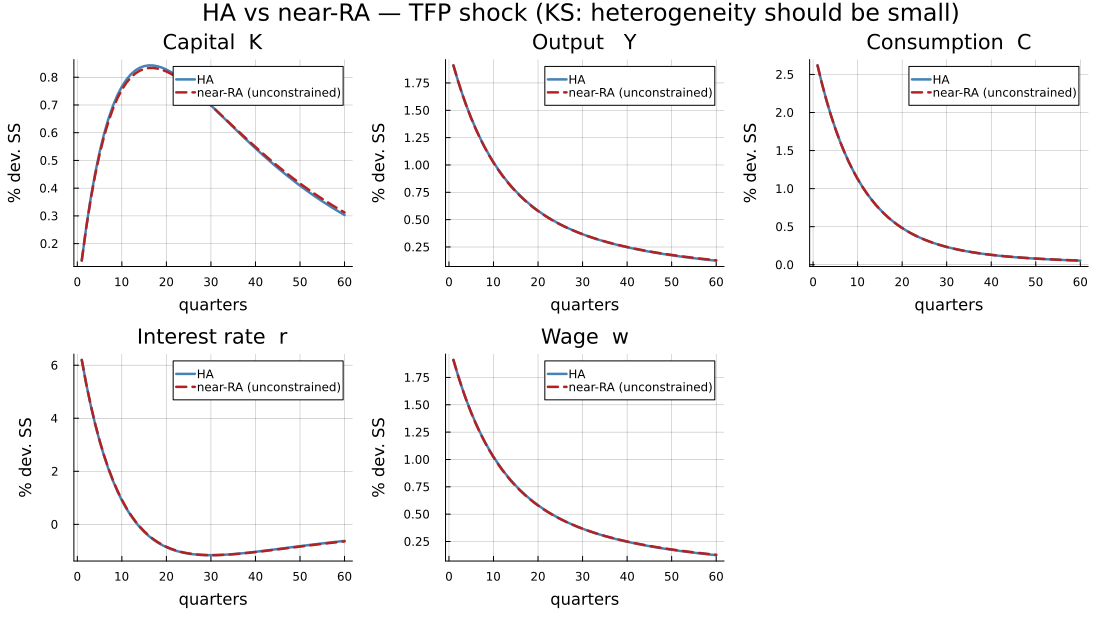

Saved  →  ks_ha_nearRA.png


In [13]:
# ── Comparison plot: HA vs near-RA IRFs ───────────────────────────────────────
ha  = (K=ha_K,  Y=ha_Y,  C=ha_C,  r=ha_r,  w=ha_w)
nra = (K=nra_K, Y=nra_Y, C=nra_C, r=nra_r, w=nra_w)

fig_irfs = plot_irfs(ha, nra; T_plot=60, save_path="ks_ha_nearRA.png")
display(fig_irfs)
println("Saved  →  ks_ha_nearRA.png")

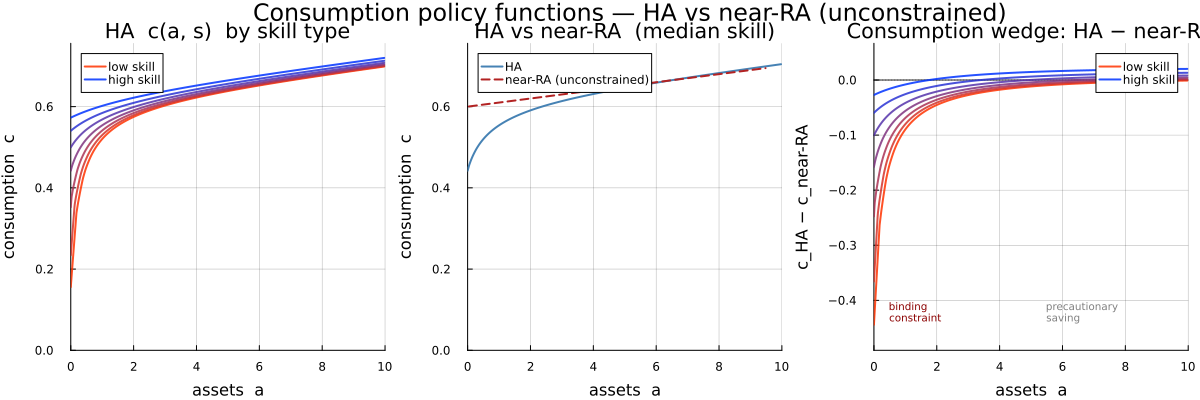

Saved  →  ks_policies_ha_nearRA.png


In [14]:
# ── Consumption policy comparison ─────────────────────────────────────────────
fig_cpol = plot_consumption_policies(c_ss, np, c_nra, np_nra;
                                     a_max_plot=10,
                                     save_path="ks_policies_ha_nearRA.png")
display(fig_cpol)
println("Saved  →  ks_policies_ha_nearRA.png")

In [ ]:
# ── Asset distribution comparison ─────────────────────────────────────────────
fig_dist = plot_distributions(D_ss, np, D_nra, np_nra;
                               a_max_plot=20,
                               save_path="ks_distributions_ha_nearRA.png")
display(fig_dist)
println("Saved  →  ks_distributions_ha_nearRA.png")